In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_excel("Decision_Tree_Large_Practice_Dataset.xlsx")
print(df.head())

  Customer_ID    Age_Group Annual_Income Time_Spent_Mins Device_Used  \
0        C001       Senior        Medium            High      Tablet   
1        C002        Youth          High             Low      Mobile   
2        C003        Youth        Medium            High      Tablet   
3        C004       Senior           Low             Low      Tablet   
4        C005  Middle-Aged        Medium             Low      Mobile   

  Items_in_Cart Discount_Available Made_Purchase  
0          Many                 No            No  
1           Few                 No            No  
2           Few                Yes           Yes  
3           Few                 No            No  
4           Few                 No            No  


In [3]:
print(df.isnull().sum())

Customer_ID           0
Age_Group             0
Annual_Income         0
Time_Spent_Mins       0
Device_Used           0
Items_in_Cart         0
Discount_Available    0
Made_Purchase         0
dtype: int64


In [4]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [5]:
X = df.drop(columns=['Customer_ID', 'Made_Purchase'])
y = df['Made_Purchase'].map({'Yes': 1, 'No': 0})

# Convert categorical columns into dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- Model Evaluation ---
Accuracy Score: 75.00%

Classification Report:
              precision    recall  f1-score   support

          No       0.74      1.00      0.85        17
         Yes       1.00      0.14      0.25         7

    accuracy                           0.75        24
   macro avg       0.87      0.57      0.55        24
weighted avg       0.82      0.75      0.67        24


Confusion Matrix:
[[17  0]
 [ 6  1]]


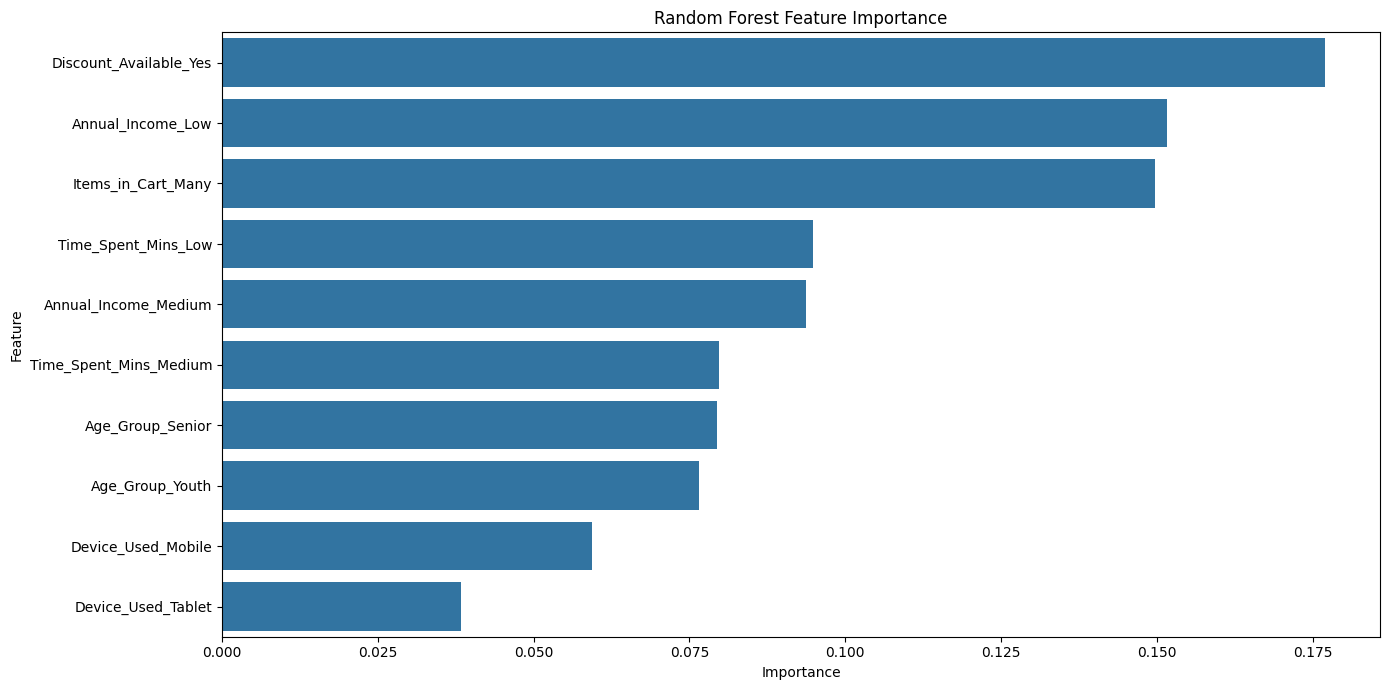

In [9]:
importances = pd.Series(model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=importances.values, y=importances.index, orient='h')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None]
}

In [11]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)



In [12]:
grid_search.fit(X_train, y_train)

print("\n=== Best Parameters Found by GridSearchCV ===")
print(grid_search.best_params_)



=== Best Parameters Found by GridSearchCV ===
{'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [13]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nTuned Model Test Accuracy: {accuracy_tuned * 100:.2f}%")


Tuned Model Test Accuracy: 79.17%
